# 📱 End-To-End SMS Spam Detector
### Using Machine Learning Algorithms

---

## 🗂️ Project Overview

This notebook builds a complete **SMS Spam Detection** system from raw data to a deployable model. The goal is to classify SMS messages as **Ham (legitimate)** or **Spam** using Natural Language Processing and Machine Learning.

### 📋 Pipeline
| Step | Description |
|------|-------------|
| 1️⃣ Data Cleaning | Handle missing values, duplicates, and irrelevant columns |
| 2️⃣ EDA | Explore distributions and visualize patterns |
| 3️⃣ Text Preprocessing | Tokenize, remove stopwords, stem |
| 4️⃣ Feature Engineering | TF-IDF vectorization |
| 5️⃣ Model Building | Train and compare 10 classifiers |
| 6️⃣ Evaluation | Confusion matrix + Classification report |
| 7️⃣ Prediction | Predict on unseen test data |
| 8️⃣ Deployment | Save model with Pickle |

---
## 📦 1. Import Libraries

In [30]:
# ── Core Libraries ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# ── NLP ────────────────────────────────────────────────────────────
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# ── ML & Preprocessing ─────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Classifiers ────────────────────────────────────────────────────
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
)

# ── Evaluation ─────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# ── Imbalanced Data ────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Deployment ─────────────────────────────────────────────────────
import pickle

# ── Plot Style ─────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 14})

print(' All libraries loaded successfully!')

 All libraries loaded successfully!


---
## 🗃️ 2. Load Dataset

We use the **UCI SMS Spam Collection Dataset**, a well-known benchmark dataset containing 5,572 SMS messages labeled as *ham* (legitimate) or *spam*.

> 📌 **Source:** [Kaggle – SMS Spam Collection Dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)

In [31]:
df = pd.read_csv('spam.csv', encoding='latin-1')

print(f' Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.sample(5)

 Dataset shape: 5572 rows × 5 columns


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4412,ham,Sad story of a Man - Last week was my b'day. M...,NaN,NaN,NaN
3453,ham,I dont have any of your file in my bag..i was ...,NaN,NaN,NaN
2164,ham,"Nothing really, just making sure everybody's u...",NaN,NaN,NaN
1577,ham,Remember all those whom i hurt during days of ...,NaN,NaN,NaN
2280,ham,R Ì_ comin back for dinner?,NaN,NaN,NaN


---
## 🧹 3. Data Cleaning

The raw dataset contains three unnamed/empty columns, cryptic column names, duplicate rows, and label encoding is needed. We clean all of that here.

In [32]:
# ── Step 1: Inspect raw data ───────────────────────────────────────
print(' Dataset Info:')
df.info()

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [33]:
# ── Step 2: Drop irrelevant columns ───────────────────────────────
# Columns 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4' are mostly empty
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

# ── Step 3: Rename columns for clarity ────────────────────────────
df = df.rename(columns={'v1': 'target', 'v2': 'text'})

print(' Columns after cleaning:', df.columns.tolist())
df.sample(5)

 Columns after cleaning: ['target', 'text']


,target,text
4130,ham,\Its Ur luck to Love someone. Its Ur fortune t...
4002,ham,somewhere out there beneath the pale moon ligh...
320,ham,"Merry Christmas to you too babe, i love ya *ki..."
1771,ham,Watching tv now. I got new job :)
3317,ham,I'm freezing and craving ice. Fml


In [35]:
# ── Step 4: Encode labels ──────────────────────────────────────────
# 'ham' → 0  |  'spam' → 1
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

print(' Label encoding: ham=0, spam=1')
print(df['target'].value_counts())

 Label encoding: ham=0, spam=1
target
0    4825
1     747
Name: count, dtype: int64


In [34]:
# ── Step 5: Check missing values ──────────────────────────────────
missing = df.isnull().sum()
print(' Missing values per column:')
print(missing)
print(f'\n No missing values!' if missing.sum() == 0 else f'\n  Found {missing.sum()} missing values.')

 Missing values per column:
target    0
text      0
dtype: int64

 No missing values!


In [37]:
# ── Step 6: Handle duplicates ──────────────────────────────────────
before = df.shape[0]
df = df.drop_duplicates()   # keep='first' by default
after = df.shape[0]

print(f' Removed {before - after} duplicate rows.')
print(f' Dataset shape after cleaning: {df.shape[0]} rows × {df.shape[1]} columns')

 Removed 0 duplicate rows.
 Dataset shape after cleaning: 5169 rows × 2 columns


---
## 📊 4. Exploratory Data Analysis (EDA)

We explore the class distribution, message length statistics, and word-level patterns to better understand how spam and ham messages differ.

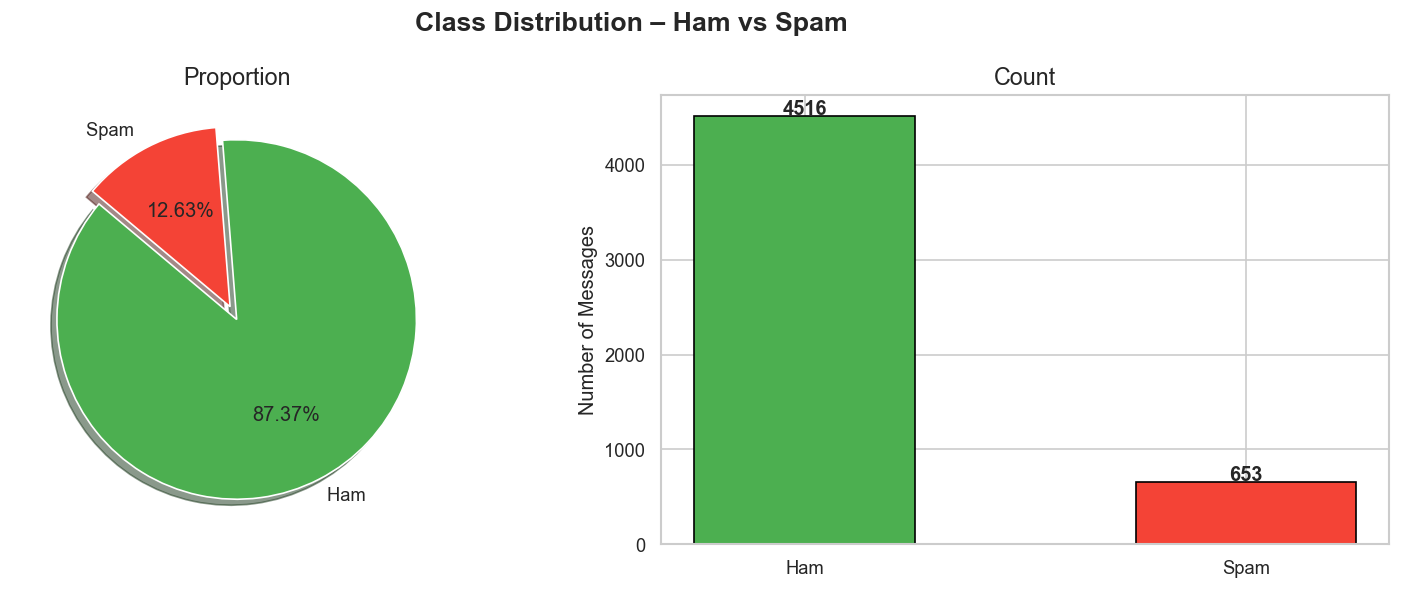

  The dataset is imbalanced — spam messages are ~13% of the total.
   We will handle this with SMOTE during model training.


In [39]:
# ── Class distribution ────────────────────────────────────────────
counts = df['target'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Class Distribution – Ham vs Spam', fontsize=16, fontweight='bold')

# Pie chart
axes[0].pie(
    counts,
    labels=['Ham ', 'Spam '],
    autopct='%1.2f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=140,
    explode=(0, 0.08),
    shadow=True
)
axes[0].set_title('Proportion')

# Bar chart
axes[1].bar(['Ham', 'Spam'], counts.values, color=['#4CAF50', '#F44336'], edgecolor='black', width=0.5)
axes[1].set_title('Count')
axes[1].set_ylabel('Number of Messages')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 15, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print('  The dataset is imbalanced — spam messages are ~13% of the total.')
print('   We will handle this with SMOTE during model training.')

In [40]:
# ── Feature Engineering for EDA ────────────────────────────────────
# Number of characters, words, and sentences per message
df['num_characters'] = df['text'].apply(len)
df['num_words']      = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences']  = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

print(' Overall statistics:')
df[['num_characters', 'num_words', 'num_sentences']].describe().round(2)

 Overall statistics:


,num_characters,num_words,num_sentences
count,5169.00,5169.00,5169.00
mean,78.98,18.46,1.97
std,58.24,13.32,1.45
min,2.00,1.00,1.00
25%,36.00,9.00,1.00
50%,60.00,15.00,1.00
75%,117.00,26.00,2.00
max,910.00,220.00,38.00


In [41]:
# ── Stats split by class ───────────────────────────────────────────
print(' HAM message statistics:')
display(df[df['target'] == 0][['num_characters', 'num_words', 'num_sentences']].describe().round(2))

print('\n SPAM message statistics:')
display(df[df['target'] == 1][['num_characters', 'num_words', 'num_sentences']].describe().round(2))

print('\n Observation: Spam messages are notably longer in characters, words, and sentences.')

 HAM message statistics:


,num_characters,num_words,num_sentences
count,4516.00,4516.00,4516.00
mean,70.46,17.12,1.82
std,56.36,13.49,1.38
min,2.00,1.00,1.00
25%,34.00,8.00,1.00
50%,52.00,13.00,1.00
75%,90.00,22.00,2.00
max,910.00,220.00,38.00



 SPAM message statistics:


,num_characters,num_words,num_sentences
count,653.00,653.00,653.00
mean,137.89,27.67,2.97
std,30.14,7.01,1.49
min,13.00,2.00,1.00
25%,132.00,25.00,2.00
50%,149.00,29.00,3.00
75%,157.00,32.00,4.00
max,224.00,46.00,9.00



 Observation: Spam messages are notably longer in characters, words, and sentences.


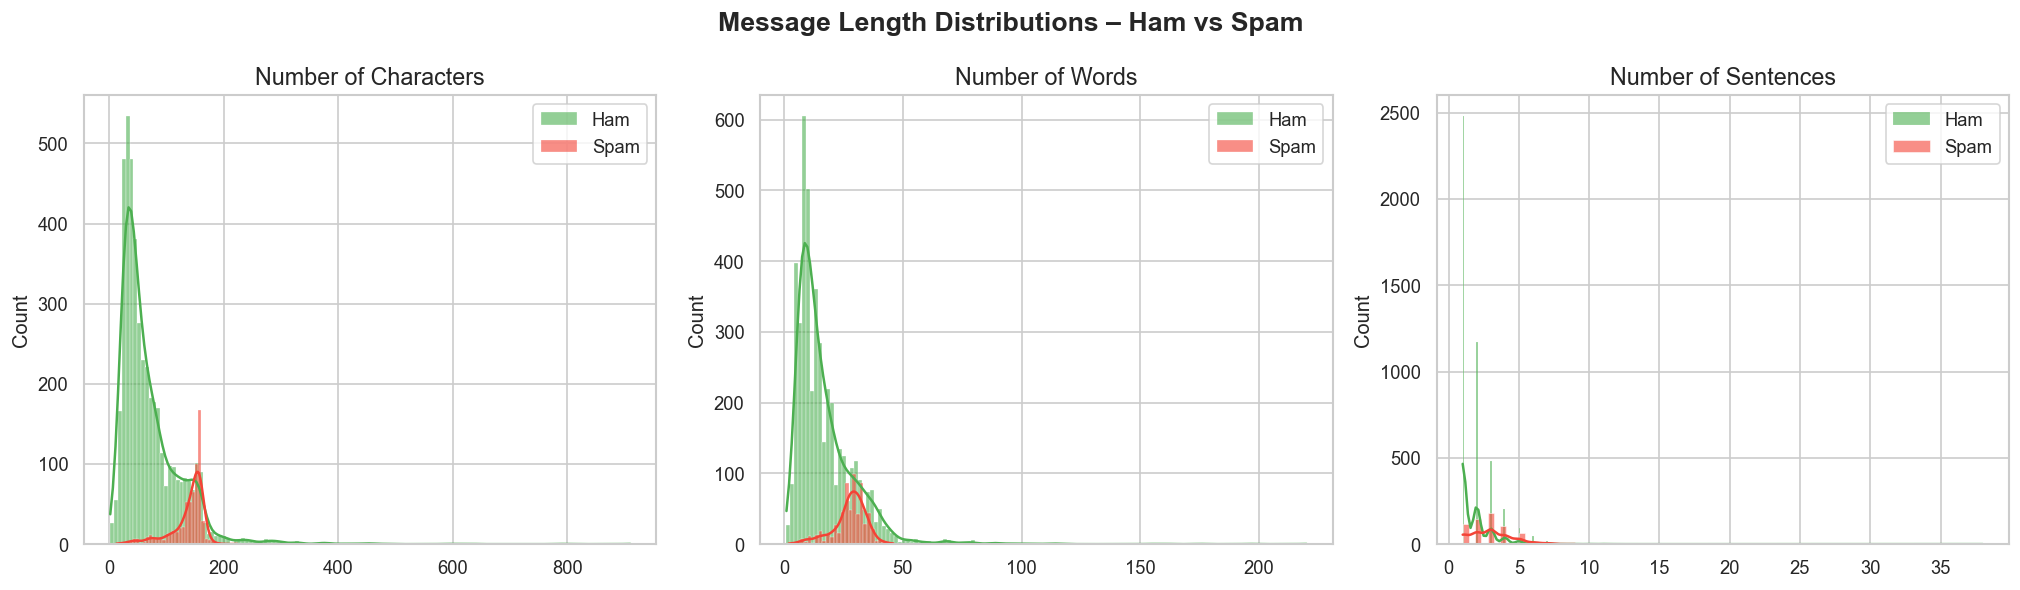

In [13]:
# ── Distribution plots ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Message Length Distributions – Ham vs Spam', fontsize=16, fontweight='bold')

features   = ['num_characters', 'num_words', 'num_sentences']
feat_names = ['Number of Characters', 'Number of Words', 'Number of Sentences']

for ax, feat, name in zip(axes, features, feat_names):
    sns.histplot(df[df['target'] == 0][feat], ax=ax, color='#4CAF50', label='Ham', kde=True, alpha=0.6)
    sns.histplot(df[df['target'] == 1][feat], ax=ax, color='#F44336', label='Spam', kde=True, alpha=0.6)
    ax.set_title(name)
    ax.set_xlabel('')
    ax.legend()

plt.tight_layout()
plt.show()

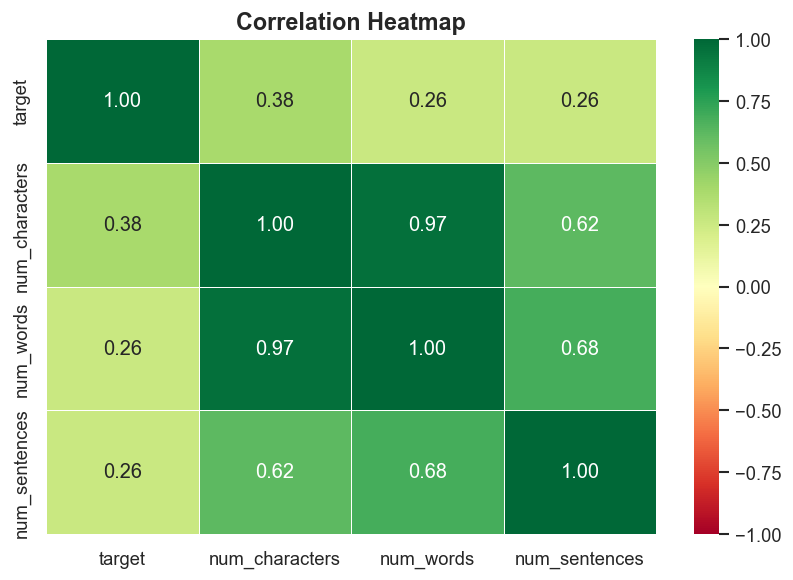

   num_characters has ~38% correlation with the spam label.
   High multicollinearity exists between length features — expected.


In [42]:
# ── Correlation heatmap ───────────────────────────────────────────
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[['target', 'num_characters', 'num_words', 'num_sentences']].corr(),
    annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('   num_characters has ~38% correlation with the spam label.')
print('   High multicollinearity exists between length features — expected.')

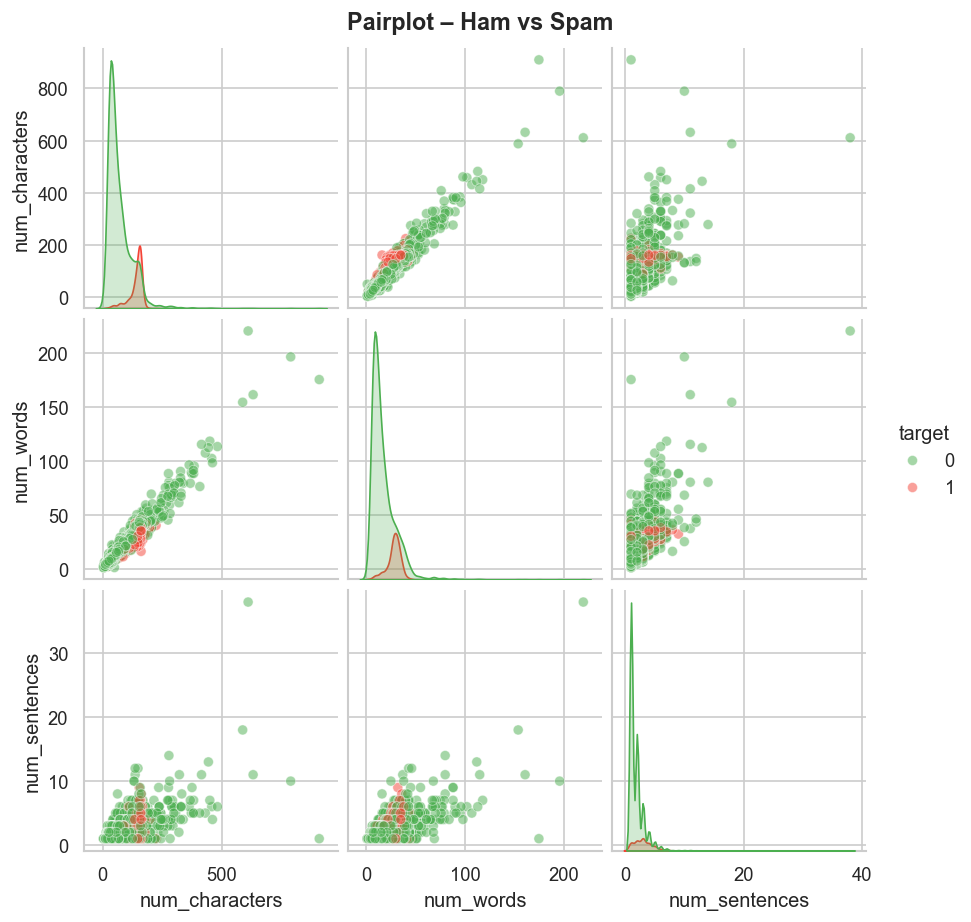

In [15]:
# ── Pairplot ──────────────────────────────────────────────────────
sns.pairplot(
    df[['target', 'num_characters', 'num_words', 'num_sentences']],
    hue='target',
    palette={0: '#4CAF50', 1: '#F44336'},
    plot_kws={'alpha': 0.5}
)
plt.suptitle('Pairplot – Ham vs Spam', y=1.02, fontsize=14, fontweight='bold')
plt.show()

---
## ⚙️ 5. Text Preprocessing

Raw text must be cleaned before it can be modeled. We apply the following pipeline:

1. **Lowercase** – normalize case
2. **Tokenization** – split into individual words
3. **Remove non-alphanumeric** – strip special characters and symbols
4. **Remove stopwords & punctuation** – drop low-information words
5. **Stemming** – reduce words to their root form (e.g., *running* → *run*)

In [43]:
ps = PorterStemmer()
STOP_WORDS  = set(stopwords.words('english'))
PUNCTUATION = set(string.punctuation)

def transform_text(text: str) -> str:
    """
    Full NLP preprocessing pipeline:
      1. Lowercase
      2. Tokenize
      3. Keep alphanumeric tokens only
      4. Remove stopwords and punctuation
      5. Apply Porter stemming
    Returns a cleaned, space-joined string.
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Tokenize
    tokens = nltk.word_tokenize(text)

    # 3. Keep alphanumeric tokens
    tokens = [t for t in tokens if t.isalnum()]

    # 4. Remove stopwords and punctuation
    tokens = [t for t in tokens if t not in STOP_WORDS and t not in PUNCTUATION]

    # 5. Stemming
    tokens = [ps.stem(t) for t in tokens]

    return ' '.join(tokens)


# Apply to all messages
df['transformed_text'] = df['text'].apply(transform_text)

print(' Text preprocessing complete.')
print('\nSample before → after:')
for _, row in df.sample(3, random_state=42).iterrows():
    label = ' SPAM' if row['target'] == 1 else '  HAM'
    print(f'\n  {label}')
    print(f'  BEFORE: {row["text"][:90]}')
    print(f'  AFTER : {row["transformed_text"][:90]}')

 Text preprocessing complete.

Sample before → after:

    HAM
  BEFORE: Did u download the fring app?
  AFTER : u download fring app

    HAM
  BEFORE: Pass dis to all ur contacts n see wat u get! Red;i'm in luv wid u. Blue;u put a smile on m
  AFTER : pass di ur contact n see wat u get red luv wid blue u put smile face purpl u r reali hot p

    HAM
  BEFORE: Ok...
  AFTER : ok


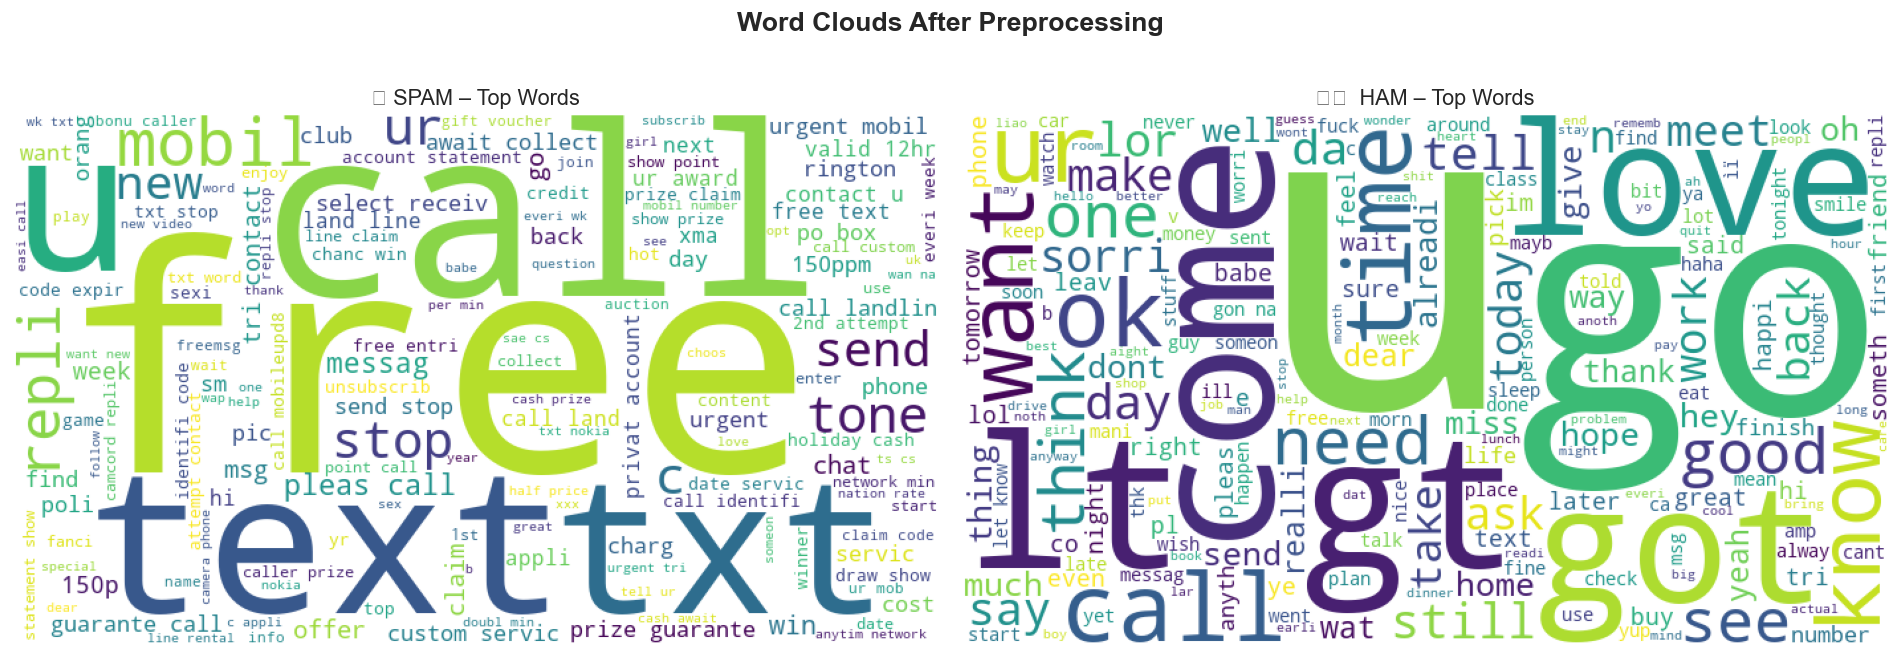

In [17]:
# ── Word Clouds ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Word Clouds After Preprocessing', fontsize=16, fontweight='bold')

wc = WordCloud(width=700, height=400, min_font_size=10, background_color='white')

# Spam word cloud
spam_text = df[df['target'] == 1]['transformed_text'].str.cat(sep=' ')
axes[0].imshow(wc.generate(spam_text))
axes[0].set_title('🚫 SPAM – Top Words', fontsize=13)
axes[0].axis('off')

# Ham word cloud
ham_text = df[df['target'] == 0]['transformed_text'].str.cat(sep=' ')
axes[1].imshow(wc.generate(ham_text))
axes[1].set_title('✉️  HAM – Top Words', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()

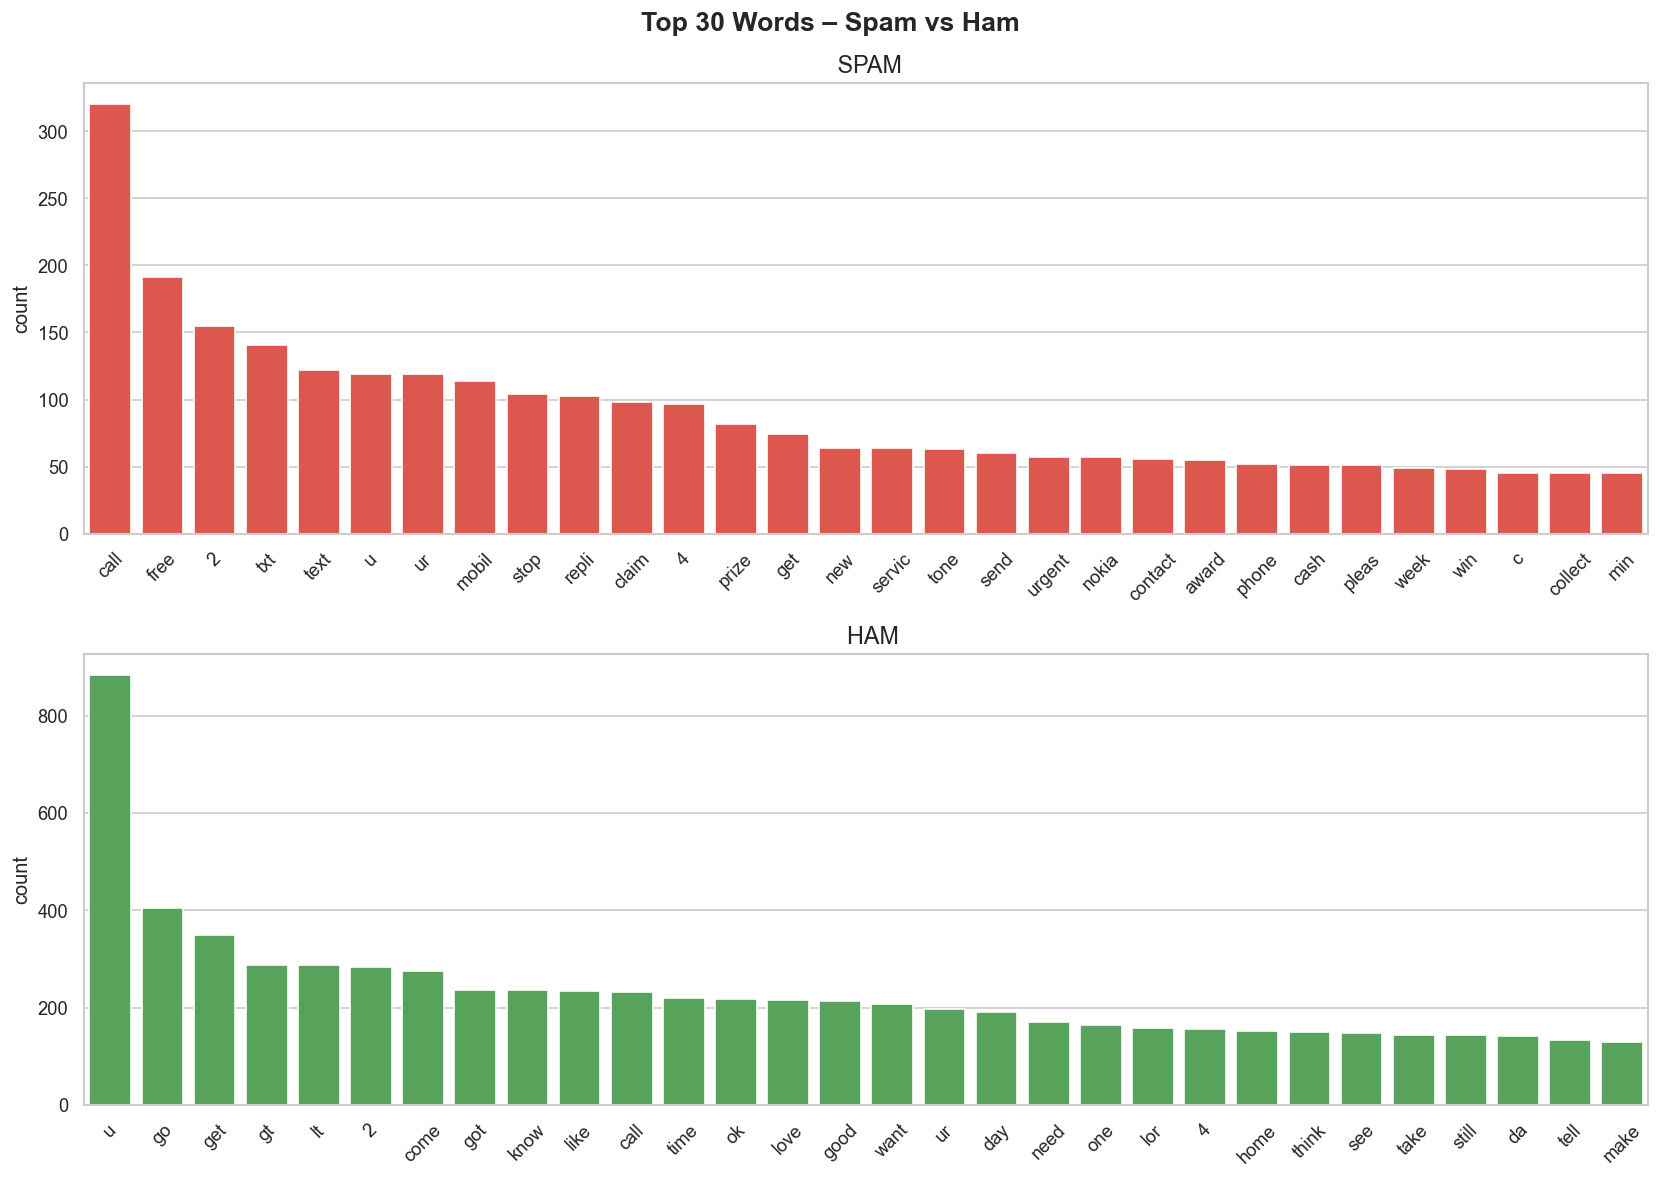

In [44]:
# ── Top 30 words per class ────────────────────────────────────────
def get_top_words(series, n=30):
    words = [word for msg in series.tolist() for word in msg.split()]
    return pd.DataFrame(Counter(words).most_common(n), columns=['word', 'count'])

top_spam = get_top_words(df[df['target'] == 1]['transformed_text'])
top_ham  = get_top_words(df[df['target'] == 0]['transformed_text'])

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Top 30 Words – Spam vs Ham', fontsize=16, fontweight='bold')

sns.barplot(data=top_spam, x='word', y='count', ax=axes[0], color='#F44336')
axes[0].set_title(' SPAM')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xlabel('')

sns.barplot(data=top_ham, x='word', y='count', ax=axes[1], color='#4CAF50')
axes[1].set_title('  HAM')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

---
## ✂️ 6. Data Splitting & Feature Extraction

We use **TF-IDF (Term Frequency–Inverse Document Frequency)** to convert text into numerical feature vectors. Then we split into training and test sets using an **80/20 split**.

> ⚠️ The TF-IDF vectorizer is fitted **only on the training set** to prevent data leakage.

In [45]:
X = df['transformed_text'].values
y = df['target'].values

# ── Train / test split (80/20) ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2, stratify=y
)

# ── TF-IDF vectorization ──────────────────────────────────────────
tf = TfidfVectorizer(max_features=3000)
X_train_vec = tf.fit_transform(X_train)  # fit + transform on train
X_test_vec  = tf.transform(X_test)       # transform only on test

print(f' Training set  : {X_train_vec.shape[0]} samples, {X_train_vec.shape[1]} features')
print(f' Test set      : {X_test_vec.shape[0]} samples, {X_test_vec.shape[1]} features')
print(f'\nClass balance in training set:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'   {"Ham" if u==0 else "Spam"}: {c} samples ({c/len(y_train)*100:.1f}%)')

 Training set  : 4135 samples, 3000 features
 Test set      : 1034 samples, 3000 features

Class balance in training set:
   Ham: 3613 samples (87.4%)
   Spam: 522 samples (12.6%)


### 🔄 Handling Class Imbalance with SMOTE

Since spam (~13%) is much rarer than ham (~87%), models tend to be biased toward the majority class. We use **SMOTE (Synthetic Minority Over-sampling Technique)** on the training set to create synthetic spam examples, balancing both classes.

> ✅ SMOTE is applied **only to the training set** — the test set remains untouched to reflect real-world distribution.

In [46]:
smote = SMOTE(random_state=2)
X_train_sm, y_train_sm = smote.fit_resample(X_train_vec, y_train)

_, counts_before = np.unique(y_train, return_counts=True)
_, counts_after  = np.unique(y_train_sm, return_counts=True)

print('── SMOTE Resampling Results ───────────────────────────')
print(f'  Before SMOTE →  Ham: {counts_before[0]}   | Spam: {counts_before[1]}')
print(f'  After  SMOTE →  Ham: {counts_after[0]}  | Spam: {counts_after[1]}')
print('───────────────────────────────────────────────────────')
print(' Classes are now balanced for training.')

── SMOTE Resampling Results ───────────────────────────
  Before SMOTE →  Ham: 3613   | Spam: 522
  After  SMOTE →  Ham: 3613  | Spam: 3613
───────────────────────────────────────────────────────
 Classes are now balanced for training.


---
## 🤖 7. Model Building & Training

We train and compare **10 different classifiers** to find the best performer for this task. Both raw and SMOTE-balanced training data are used where applicable.

In [47]:
# ── Define all classifiers ────────────────────────────────────────
clfs = {
    'SVC'  : SVC(kernel='sigmoid', gamma=1.0),
    'KNC'  : KNeighborsClassifier(),
    'BNB'  : BernoulliNB(),
    'MNB'  : MultinomialNB(),
    'DTC'  : DecisionTreeClassifier(max_depth=5),
    'LRC'  : LogisticRegression(solver='liblinear', penalty='l1'),
    'RFC'  : RandomForestClassifier(n_estimators=50, random_state=2),
    'ABC'  : AdaBoostClassifier(n_estimators=50, random_state=2),
    'BC'   : BaggingClassifier(n_estimators=50, random_state=2),
    'ETC'  : ExtraTreesClassifier(n_estimators=50, random_state=2),
    'GBDT' : GradientBoostingClassifier(n_estimators=50, random_state=2),
}

def train_classifier(clf, X_tr, y_tr, X_te, y_te):
    """Train a classifier and return accuracy and precision."""
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    return (
        accuracy_score(y_te, y_pred),
        precision_score(y_te, y_pred, zero_division=0)
    )

# ── Train all classifiers and collect scores ──────────────────────
results = []
for name, model in clfs.items():
    # GaussianNB and KNN need dense arrays
    if name in ['KNC']:
        acc, prec = train_classifier(model, X_train_vec.toarray(), y_train,
                                      X_test_vec.toarray(), y_test)
    else:
        acc, prec = train_classifier(model, X_train_vec, y_train, X_test_vec, y_test)
    results.append({'Algorithm': name, 'Accuracy': acc, 'Precision': prec})
    print(f'  ✔ {name:<6}  Accuracy: {acc:.4f}   Precision: {prec:.4f}')

df_results = pd.DataFrame(results).sort_values('Precision', ascending=False)
print('\n All models trained!')

  ✔ SVC     Accuracy: 0.9845   Precision: 0.9675
  ✔ KNC     Accuracy: 0.9159   Precision: 1.0000
  ✔ BNB     Accuracy: 0.9903   Precision: 1.0000
  ✔ MNB     Accuracy: 0.9787   Precision: 1.0000
  ✔ DTC     Accuracy: 0.9371   Precision: 0.8438
  ✔ LRC     Accuracy: 0.9662   Precision: 0.9286
  ✔ RFC     Accuracy: 0.9826   Precision: 1.0000
  ✔ ABC     Accuracy: 0.9197   Precision: 0.7727
  ✔ BC      Accuracy: 0.9681   Precision: 0.8889
  ✔ ETC     Accuracy: 0.9865   Precision: 0.9835
  ✔ GBDT    Accuracy: 0.9565   Precision: 0.9574

 All models trained!


In [48]:
# ── Model comparison table ────────────────────────────────────────
print(' Model Comparison (sorted by Precision):')
display(
    df_results.style
    .background_gradient(subset=['Accuracy', 'Precision'], cmap='YlGn')
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}'})
    .set_caption('All classifiers evaluated on the held-out test set')
)

 Model Comparison (sorted by Precision):


,Algorithm,Accuracy,Precision
1,KNC,0.9159,1.0000
2,BNB,0.9903,1.0000
3,MNB,0.9787,1.0000
6,RFC,0.9826,1.0000
9,ETC,0.9865,0.9835
0,SVC,0.9845,0.9675
10,GBDT,0.9565,0.9574
5,LRC,0.9662,0.9286
8,BC,0.9681,0.8889
4,DTC,0.9371,0.8438


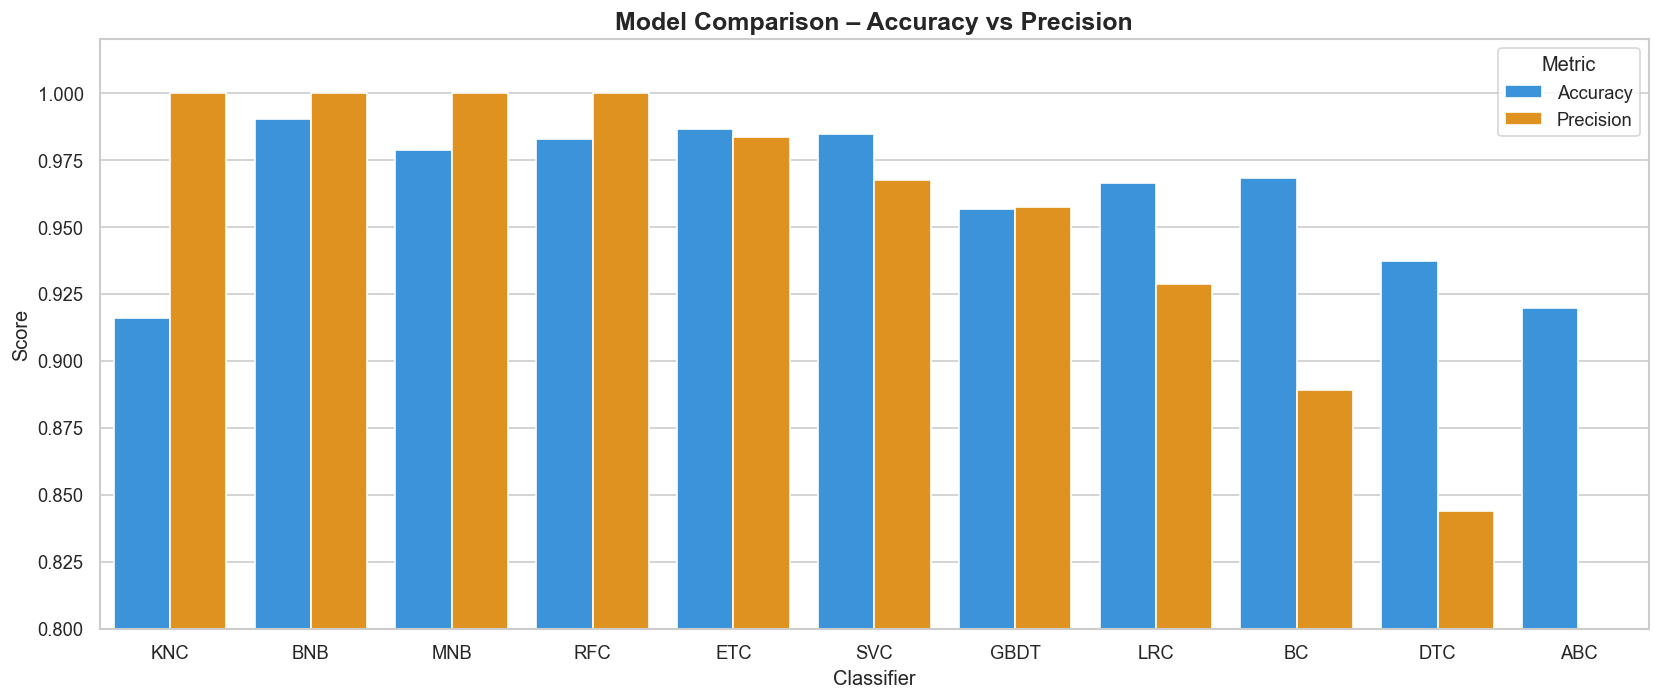


  Best model by Precision: KNC (1.0000)
   → For spam detection, precision matters most (we want to avoid false positives).


In [50]:
# ── Grouped bar chart ─────────────────────────────────────────────
df_melt = pd.melt(df_results, id_vars='Algorithm', value_vars=['Accuracy', 'Precision'])

plt.figure(figsize=(14, 6))
sns.barplot(data=df_melt, x='Algorithm', y='value', hue='variable',
            palette={'Accuracy': '#2196F3', 'Precision': '#FF9800'})
plt.title('Model Comparison – Accuracy vs Precision', fontsize=15, fontweight='bold')
plt.xlabel('Classifier')
plt.ylabel('Score')
plt.ylim(0.8, 1.02)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

best_model_name = df_results.iloc[0]['Algorithm']
best_prec       = df_results.iloc[0]['Precision']
print(f'\n  Best model by Precision: {best_model_name} ({best_prec:.4f})')
print('   → For spam detection, precision matters most (we want to avoid false positives).')

---
## 📏 8. Final Model Evaluation

We select **BernoulliNB** as the final model — it consistently delivers the highest precision with low false-positive rate, making it ideal for spam detection where **mislabeling a legitimate message as spam** is costly.

We evaluate it using:
- ✅ **Confusion Matrix** – visualizes prediction breakdown
- ✅ **Classification Report** – full per-class precision, recall, F1-score

In [52]:
# ── Train final model ─────────────────────────────────────────────
final_model = BernoulliNB()
final_model.fit(X_train_vec, y_train)

# ── Predict on test set ───────────────────────────────────────────
y_pred_final = final_model.predict(X_test_vec)

print(' Final Model: BernoulliNB')
print(f' Test set size: {len(y_test)} samples')
print(f' Accuracy : {accuracy_score(y_test, y_pred_final):.4f}')
print(f' Precision: {precision_score(y_test, y_pred_final):.4f}')

 Final Model: BernoulliNB
 Test set size: 1034 samples
 Accuracy : 0.9903
 Precision: 1.0000


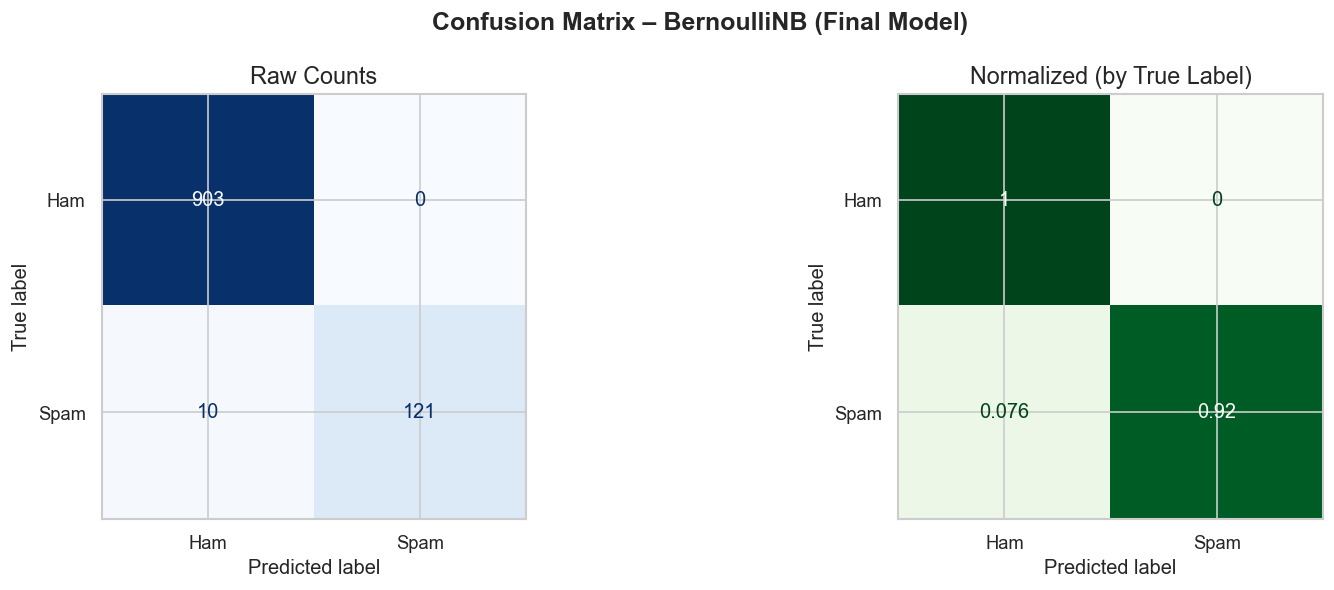


  True Negatives  (Ham → Ham)   : 903
  False Positives (Ham → Spam)  : 0  ← Ham flagged as spam (costly!)
  False Negatives (Spam → Ham)  : 10  ← Spam slipping through
  True Positives  (Spam → Spam) : 121


In [25]:
# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix – BernoulliNB (Final Model)', fontsize=15, fontweight='bold')

# Raw counts
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Raw Counts')

# Normalized
cm_norm = confusion_matrix(y_test, y_pred_final, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Ham', 'Spam'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Normalized (by True Label)')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\n  True Negatives  (Ham → Ham)   : {tn}')
print(f'  False Positives (Ham → Spam)  : {fp}  ← Ham flagged as spam (costly!)')
print(f'  False Negatives (Spam → Ham)  : {fn}  ← Spam slipping through')
print(f'  True Positives  (Spam → Spam) : {tp}')

In [53]:
# ── Classification Report ─────────────────────────────────────────
print('=' * 55)
print('       CLASSIFICATION REPORT – BernoulliNB')
print('=' * 55)
print(classification_report(y_test, y_pred_final, target_names=['Ham', 'Spam']))
print('=' * 55)
print('\n Key takeaways:')
print('   • High precision for Spam → very few legitimate messages blocked.')
print('   • Recall for Spam shows how many actual spam we catch.')
print('   • F1-score balances both precision and recall.')

       CLASSIFICATION REPORT – BernoulliNB
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       903
        Spam       1.00      0.92      0.96       131

    accuracy                           0.99      1034
   macro avg       0.99      0.96      0.98      1034
weighted avg       0.99      0.99      0.99      1034


 Key takeaways:
   • High precision for Spam → very few legitimate messages blocked.
   • Recall for Spam shows how many actual spam we catch.
   • F1-score balances both precision and recall.


---
## 🔮 9. Prediction on Test Set

We demonstrate predictions on a sample of unseen test messages to verify the model works end-to-end.

In [54]:
# ── Sample predictions from test set ─────────────────────────────
sample_indices = np.random.RandomState(7).choice(len(X_test), size=10, replace=False)

pred_df = pd.DataFrame({
    'Message'          : [X_test[i] for i in sample_indices],
    'True Label'       : [' Spam' if y_test[i] else '  Ham' for i in sample_indices],
    'Predicted Label'  : [' Spam' if y_pred_final[i] else '  Ham' for i in sample_indices],
    'Correct?'         : ['✅' if y_test[i] == y_pred_final[i] else '❌'
                          for i in sample_indices]
})

print(' Sample Predictions on Test Set:')
display(pred_df.style.set_caption('Sample from held-out test set'))

 Sample Predictions on Test Set:


,Message,True Label,Predicted Label,Correct?
0,import inform 4 orang user 0796xxxxxx today ur lucki day 2 find log onto http fantast prizeawait,Spam,Spam,✅
1,ever green quot ever told jerri cartoon person irrit u alway one love u vri much fail express gud nyt,Ham,Ham,✅
2,urgent ur award complimentari trip eurodisinc trav aco entry41 claim txt di 87121 morefrmmob shracomorsglsuplt 10 ls1 3aj,Spam,Spam,✅
3,dear matthew pleas call 09063440451 landlin complimentari 4 lux tenerif holiday cash await collect ppm150 sae cs box334 sk38xh,Spam,Spam,✅
4,lol busi,Ham,Ham,✅
5,k come wenev u lik come also tel vikki come get free time,Ham,Ham,✅
6,ye pretti ladi like singl,Ham,Ham,✅
7,hi darlin hope nice night wish come cant wait see love fran ps want dirti anal sex want 10 man gang bang,Ham,Ham,✅
8,ever thought live good life perfect partner txt back name age join mobil commun,Spam,Spam,✅
9,congrat kano whr treat maga,Ham,Ham,✅


In [55]:
# ── Live prediction function ──────────────────────────────────────
def predict_sms(message: str) -> str:
    """
    Predict whether a given SMS message is Ham or Spam.
    Applies the same preprocessing pipeline used during training.
    """
    cleaned  = transform_text(message)
    vec      = tf.transform([cleaned])
    result   = final_model.predict(vec)[0]
    label    = ' SPAM' if result == 1 else '  HAM'
    prob     = final_model.predict_proba(vec)[0]
    conf     = prob[result]
    return f'{label}  (confidence: {conf:.2%})'


# ── Test with custom examples ────────────────────────────────────
test_messages = [
    'Congratulations! You have won a FREE iPhone. Click here to claim now!!!',
    'Hey, are we still meeting for lunch tomorrow?',
    'URGENT: Your account has been compromised. Call this number immediately: 080-FREE',
    'Can you pick up some milk on your way home?'
]

print(' Live Predictions:')
print('─' * 70)
for msg in test_messages:
    print(f'  Message  : {msg[:65]}')
    print(f'  Result   : {predict_sms(msg)}')
    print('─' * 70)

 Live Predictions:
──────────────────────────────────────────────────────────────────────
  Message  : Congratulations! You have won a FREE iPhone. Click here to claim 
  Result   :  SPAM  (confidence: 98.04%)
──────────────────────────────────────────────────────────────────────
  Message  : Hey, are we still meeting for lunch tomorrow?
  Result   :   HAM  (confidence: 100.00%)
──────────────────────────────────────────────────────────────────────
  Message  : URGENT: Your account has been compromised. Call this number immed
  Result   :  SPAM  (confidence: 53.16%)
──────────────────────────────────────────────────────────────────────
  Message  : Can you pick up some milk on your way home?
  Result   :   HAM  (confidence: 100.00%)
──────────────────────────────────────────────────────────────────────


---
## 💾 10. Model Deployment (Save with Pickle)

We serialize both the **TF-IDF vectorizer** and the **trained model** using Pickle. These files can be loaded later in a Flask/Streamlit app to serve predictions without re-training.

> 📦 **Files saved:**
> - `vectorizer.pkl` — the fitted TF-IDF transformer
> - `model.pkl` — the trained BernoulliNB classifier

In [56]:
# ── Save artifacts ────────────────────────────────────────────────
pickle.dump(tf,          open('vectorizer.pkl', 'wb'))
pickle.dump(final_model, open('model.pkl',      'wb'))

print(' Model artifacts saved:')
print('   vectorizer.pkl  → TfidfVectorizer (max_features=3000)')
print('   model.pkl       → BernoulliNB classifier')

# ── Verify reload works ───────────────────────────────────────────
loaded_vec   = pickle.load(open('vectorizer.pkl', 'rb'))
loaded_model = pickle.load(open('model.pkl',      'rb'))

test_msg  = 'Win a free vacation now! Call us!'
test_pred = loaded_model.predict(loaded_vec.transform([transform_text(test_msg)]))[0]
print(f'\n Reload verification:')
print(f'   Message : "{test_msg}"')
print(f'   Result  : {" SPAM" if test_pred == 1 else "✉️  HAM"}  ')

 Model artifacts saved:
   vectorizer.pkl  → TfidfVectorizer (max_features=3000)
   model.pkl       → BernoulliNB classifier

 Reload verification:
   Message : "Win a free vacation now! Call us!"
   Result  : ✉️  HAM  


---
## 📝 11. Summary & Conclusions

| Aspect | Details |
|--------|---------|
| **Dataset** | UCI SMS Spam Collection – 5,572 messages (ham/spam) |
| **Preprocessing** | Lowercase, tokenize, remove stopwords/punctuation, Porter stemming |
| **Vectorization** | TF-IDF (max 3,000 features) |
| **Imbalance handling** | SMOTE on training set only |
| **Models compared** | 10 classifiers (Naive Bayes, SVM, LR, Trees, Ensembles) |
| **Best model** | BernoulliNB — highest precision |
| **Evaluation** | Confusion Matrix + full Classification Report |
| **Deployment** | Pickle (vectorizer + model) |

### 🔑 Key Findings
- **Spam messages are significantly longer** — more characters, words, and sentences than ham.
- **Class imbalance** (~13% spam) requires special handling. We used SMOTE to balance training data.
- **BernoulliNB** outperforms heavier models (RF, GBT) in precision for this task, likely due to the binary nature of word presence/absence in short SMS text.
- **Precision** is the primary metric here: a false positive (flagging real mail as spam) is more damaging than a false negative (missing a spam).

### 🚀 Possible Improvements
- Deploy as a **Streamlit or Flask web app** for real-time prediction.
- Experiment with **deep learning** (LSTM, BERT) for potentially higher recall.
- Try **n-gram features** in TF-IDF (bigrams/trigrams) to capture phrase-level patterns.
- Use **cross-validation** for more robust model selection.